In [ ]:
!pip install -U pip -q
!pip install -U torchao peft transformers datasets accelerate pyarrow underthesea matplotlib -q

In [37]:
import os, json, time, zipfile, math, gc
import numpy as np
from pathlib import Path
from datetime import datetime
from itertools import cycle

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from datasets import load_dataset, Dataset, DatasetDict, load_from_disk, Features, Value, ClassLabel
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup, get_linear_schedule_with_warmup
import shutil
from peft import get_peft_model, LoraConfig, TaskType
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')

PyTorch 2.10.0+cu128 | Device: cuda
GPU: Tesla T4 | VRAM: 15.6GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted')

In [21]:
# CONFIG - Chỉnh tại đây
CONFIG = {
    # Đường dẫn file
    'zip_path'    : '/content/drive/MyDrive/Học sâu 252AI31001/Data_Preprocessed.zip',
    'extract_dir' : '/kaggle/working/parquet_files',
    'cache_dir'   : '/kaggle/working/hf_cache',
    'dataset_path': '/kaggle/working/hf_dataset',
    # Thư mục lưu checkpoint + log + best model
    'output_dir'  : '/kaggle/working/checkpoints',

    # Cấu hình Model
    'model_name'  : 'vinai/phobert-base',
    'max_length'  : 256,
    'lora_r'      : 16,
    'lora_alpha'  : 32,
    'lora_dropout': 0.1,

    # Tham số Train
    'batch_size'          : 32,
    'grad_accum_steps'    : 2,
    'learning_rate'       : 2e-5,
    'epochs'              : 10,
    'warmup_ratio'        : 0.1,
    'grad_clip'           : 1.0,

    # Cấu hình Loss
    'focal_gamma' : 2.0,
    'focal_alpha' : 0.5,

    # Điểm dừng sớm
    'early_stop_patience': 3, # dừng nếu F1 không tăng sau 3 lần validate

    # Tỷ lệ chia
    'val_size'  : 0.1,
    'test_size' : 0.1,
    'seed'      : 42,
    'num_proc'  : 4,

    'eval_every_steps': 1000,   # Buoc danh gia model
    'save_every_steps': 2000,   # Buoc luu checkpoint
}

# Tao thu muc luu tru
for p in ['output_dir', 'extract_dir', 'cache_dir']:
    Path(CONFIG[p]).mkdir(parents=True, exist_ok=True)

# Duong dan file out
CKPT_PATH       = os.path.join(CONFIG['output_dir'], 'checkpoint.pt')
BEST_MODEL_PATH = os.path.join(CONFIG['output_dir'], 'best_model.pt')
LOG_PATH        = os.path.join(CONFIG['output_dir'], 'training_log.json')

In [3]:
# Duong dan file goc
PARQUET_DIR = "/kaggle/input/datasets/bangta205/scam-detection-datasets-preprocessed" 

print("Lien ket file goc...")
# Doc file tu dia
raw_dataset = load_dataset(
    "parquet", 
    data_files=os.path.join(PARQUET_DIR, "*.parquet"), 
    split="train",
    keep_in_memory=False
)

# Ep kieu nhan
raw_dataset = raw_dataset.cast_column("label", ClassLabel(num_classes=2, names=["clean", "scam"]))

# --- KIEM TRA LECH NHAN ---
print("\n   KIEM TRA LECH NHAN")
total_records = len(raw_dataset)

print("Dang nap rieng nhan...")
# Doc rieng cot nhan
label_ds = load_dataset(
    "parquet", 
    data_files=os.path.join(PARQUET_DIR, "*.parquet"), 
    split="train", 
    columns=["label"]
)
labels_array = np.array(label_ds["label"], dtype=np.int8)

# Dem so luong nhan
counts = np.bincount(labels_array)
clean_count = counts[0] if len(counts) > 0 else 0
scam_count = counts[1] if len(counts) > 1 else 0

print(f"Tong so ban ghi: {total_records:,}")
print(f"  - CLEAN (0): {clean_count:,} dong ({clean_count/total_records*100:.2f}%)")
print(f"  - SCAM (1) : {scam_count:,} dong ({scam_count/total_records*100:.2f}%)")

# Xoa mang tam
del label_ds
gc.collect()

# --- CAN BANG DU LIEU ---
print("\n   CAN BANG NHAN")
minority_size = min(clean_count, scam_count)
print(f"-> Boc moi ben: {minority_size:,} dong.")

# Tim vi tri nhan
clean_indices = np.where(labels_array == 0)[0]
scam_indices = np.where(labels_array == 1)[0]

print("Dang lay mau...")
# Lay mau ngau nhien
np.random.seed(CONFIG['seed'])
if clean_count > scam_count:
    chosen_clean = np.random.choice(clean_indices, size=minority_size, replace=False)
    chosen_scam = scam_indices
else:
    chosen_clean = clean_indices
    chosen_scam = np.random.choice(scam_indices, size=minority_size, replace=False)

# Tron deu chi muc
chosen_all = np.concatenate([chosen_clean, chosen_scam])
np.random.shuffle(chosen_all)

print("Dang trich xuat...")
# Trich xuat du lieu
balanced_dataset = raw_dataset.select(chosen_all, keep_in_memory=True)
print(f"Tong so sau can bang: {len(balanced_dataset):,} dong.")

# Xoa mang tam
del labels_array, clean_indices, scam_indices, chosen_clean, chosen_scam, chosen_all
gc.collect()

# --- MAP ---
print("\n   CHUAN HOA DATA")
# Tao cau truc moi
new_features = balanced_dataset.features.copy()
new_features["n_subs_norm"] = Value("float32")

# Ham chuan hoa metadata
def preprocess_function(examples):
    subs = np.array(examples['n_subscribers'])
    max_s = 5000000
    examples['n_subs_norm'] = np.log1p(subs) / np.log1p(max_s)
    examples['label'] = [int(l) for l in examples['label']]
    return examples

# Chuan hoa voi batch lon
processed_dataset = balanced_dataset.map(
    preprocess_function, 
    batched=True, 
    batch_size=250000, 
    writer_batch_size=250000, 
    features=new_features, 
    num_proc=CONFIG['num_proc'],
    keep_in_memory=True,
    load_from_cache_file=False,
    desc="Chuan hoa"
)

# --- CHIA TAP DATA ---
print("\n   CHIA TAP DATA")
# Tinh ty le chia
holdout = CONFIG["val_size"] + CONFIG["test_size"]

# Tach tap Train
splits = processed_dataset.train_test_split(
    test_size=holdout,
    seed=CONFIG["seed"],
    stratify_by_column="label",
    keep_in_memory=True
)
train_ds = splits['train']

# Tach Val va Test
test_val_splits = splits['test'].train_test_split(
    test_size=0.5,
    seed=CONFIG["seed"],
    stratify_by_column="label",
    keep_in_memory=True
)
val_ds = test_val_splits['train']
test_ds = test_val_splits['test']

print(f"  - TRAIN : {len(train_ds):,}")
print(f"  - VAL   : {len(val_ds):,}")
print(f"  - TEST  : {len(test_ds):,}")

# Don rac bo nho
gc.collect()

Lien ket file goc...


Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

Casting the dataset:   0%|          | 0/34245696 [00:00<?, ? examples/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Tong so ban ghi: 34,245,696
  - CLEAN (0): 34,158,572 dong (99.75%)
  - SCAM (1) : 87,124 dong (0.25%)

   CAN BANG NHAN
-> Boc moi ben: 87,124 dong.
Dang lay mau...
Dang trich xuat...
Tong so sau can bang: 174,248 dong.

   CHUAN HOA DATA


Chuan hoa (num_proc=4):   0%|          | 0/174248 [00:00<?, ? examples/s]


   CHIA TAP DATA
  - TRAIN : 139,398
  - VAL   : 17,425
  - TEST  : 17,425


22

In [ ]:
# TOKENIZE TOAN BO DATA 
print("Tokenize...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

# Ham tokenize hang loat
def tokenize_batch_function(examples):
    return tokenizer(
        examples['cleaned_text'],
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True
    )

# Chuan hoa tokenize luong
tokenized_train = train_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Train")
tokenized_val = val_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Val")
tokenized_test = test_ds.map(tokenize_batch_function, batched=True, batch_size=50000, num_proc=CONFIG['num_proc'], keep_in_memory=True, load_from_cache_file=False, desc="Tokenize Test")

# tokenized_train = load_from_disk("/kaggle/working/scam_dataset_tokenized/train")
# tokenized_val   = load_from_disk("/kaggle/working/scam_dataset_tokenized/validation")
# tokenized_test  = load_from_disk("/kaggle/working/scam_dataset_tokenized/test")

# PYTORCH DATASET
class ScamDataset(Dataset):
    def __init__(self, hf_tokenized_dataset):
        self.dataset = hf_tokenized_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Xu ly neu idx la list
        if isinstance(idx, list):
            item = self.dataset[idx]
            # Doc va ep kieu mang
            return {
                'input_ids'     : torch.tensor(item['input_ids'], dtype=torch.long),
                'attention_mask': torch.tensor(item['attention_mask'], dtype=torch.long),
                'metadata'      : torch.tensor(
                    [[float(h), float(v), float(n)] for h, v, n in zip(item['has_url'], item['verified'], item['n_subs_norm'])],
                    dtype=torch.float
                ),
                'label'         : torch.tensor([int(l) for l in item['label']], dtype=torch.long)
            }
        
        # Xu ly neu idx la so don
        item = self.dataset[int(idx)]
        return {
            'input_ids'     : torch.tensor(item['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(item['attention_mask'], dtype=torch.long),
            'metadata'      : torch.tensor(
                [float(item['has_url']), float(item['verified']), float(item['n_subs_norm'])],
                dtype=torch.float
            ),
            'label'         : torch.tensor(int(item['label']), dtype=torch.long)
        }

# Khoi tao dataset
train_dataset_pytorch = ScamDataset(tokenized_train)
val_dataset_pytorch   = ScamDataset(tokenized_val)
test_dataset_pytorch  = ScamDataset(tokenized_test)


# DATALOADER
print("\nKhoi tao DataLoader...")
train_loader = DataLoader(
    train_dataset_pytorch, 
    batch_size=CONFIG['batch_size'],
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

val_loader   = DataLoader(
    val_dataset_pytorch,   
    batch_size=CONFIG['batch_size']*2,
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

test_loader  = DataLoader(
    test_dataset_pytorch,  
    batch_size=CONFIG['batch_size']*2,
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

# TINH STEP THEO DATA 
# Lay do dai loader lam step
steps_per_epoch = len(train_loader) 
total_steps = CONFIG['epochs'] * steps_per_epoch
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

# In thong so kiem tra
print(f"\nConfig OK | Device: {device}")
print(f"Actual Train: {CONFIG['epochs']} epochs x {steps_per_epoch:,} steps = {total_steps:,} total steps")
print(f"Warmup steps: {warmup_steps:,} | Effective batch size: {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")


Khoi tao DataLoader...

Config OK | Device: cuda
Actual Train: 10 epochs x 4,357 steps = 43,570 total steps
Warmup steps: 4,357 | Effective batch size: 64


In [1]:
# print("Hop nhat cac tap du lieu da tokenize...")
# # Gop 3 tap du lieu vao mot cau truc DatasetDict
# final_tokenized_dataset = DatasetDict({
#     'train': tokenized_train,
#     'validation': tokenized_val,
#     'test': tokenized_test
# })

# # Thiet lap duong dan luu file
# SAVE_DIR = "/kaggle/working/scam_dataset_tokenized"
# ZIP_OUTPUT = "/kaggle/working/scam_dataset_tokenized"

# print("Luu cung xuong o dia virtual...")
# final_tokenized_dataset.save_to_disk(SAVE_DIR)
# print(f"Da luu xong tai: {SAVE_DIR}")

# print("\nNen thanh file .zip de tai ve...")
# # Nen zip folder vua luu de tải về máy dễ dàng
# shutil.make_archive(ZIP_OUTPUT, 'zip', SAVE_DIR)
# print(f"File san sang tai ve: {ZIP_OUTPUT}.zip")

In [ ]:
# # Thu muc nguon tu input
# INPUT_DIR = "/kaggle/input/datasets/bangta205/scam-dataset-tokenized"
# # Thu muc dich den working
# WORKING_DIR = "/kaggle/working/scam_dataset_tokenized"

# # Tien hanh sao chep
# if os.path.exists(INPUT_DIR):
#     if os.path.exists(WORKING_DIR):
#         # Xoa neu trung folder
#         shutil.rmtree(WORKING_DIR)
#     # Copy nguyen folder sang
#     shutil.copytree(INPUT_DIR, WORKING_DIR)
#     print("Copy data thanh cong")
# else:
#     print("Khong tim thay nguon")

Copy data thanh cong


In [2]:
# !ls -lh /kaggle/working

In [24]:
# KIEN TRUC MODEL 
class ScamClassifier(nn.Module):
    """
    PhoBERT encoder + metadata features -> binary classifier
    Input : text token + [has_url, verified, n_subs_norm]
    Output: logit [not_scam, scam]
    """
    def __init__(self, model_name, num_meta=3, num_classes=2):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden         = self.encoder.config.hidden_size   # 768
        self.head      = nn.Sequential(
            nn.Linear(hidden + num_meta, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, metadata):
        out  = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls  = out.last_hidden_state[:, 0, :]   # [CLS] embedding
        x    = torch.cat([cls, metadata], dim=1)
        return self.head(x)


# Khoi tao model goc
model = ScamClassifier(CONFIG['model_name'])

# CAU HINH LORA LOP ENCODER 
lora_cfg = LoraConfig(
    task_type      = TaskType.SEQ_CLS, # Doi thanh SEQ_CLS
    r              = CONFIG['lora_r'],
    lora_alpha     = CONFIG['lora_alpha'],
    lora_dropout   = CONFIG['lora_dropout'],
    target_modules = ['query', 'key', 'value'],
    bias           = 'none'
)

# Ap dung LoRA cho encoder
model.encoder = get_peft_model(model.encoder, lora_cfg)

# MO KHOA COMPONENT PHAN LOAI 
# Mo khoa gradient cho head
for param in model.head.parameters():
    param.requires_grad = True

# Kiem tra tham so train
model.encoder.print_trainable_parameters()

# Đẩy model len thiet bi
model = model.to(device)
print('Model ready')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 884,736 || all params: 135,883,008 || trainable%: 0.6511
Model ready


In [29]:
# Ham Focal Loss + Optimizer + Scheduler
class FocalLoss(nn.Module):
    """
    Focal Loss - Giam dong gop samples de
    gamma : focusing parameter (2 la chuan)
    alpha : weight cho class Scam=True (0.5 do data can bang)
    """
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        # Trọng số nhãn mặc định
        self.register_buffer('weight', torch.tensor([1.0 - alpha, alpha], dtype=torch.float))

    def forward(self, logits, targets):
        # Ép weight theo thiết bị logits
        weight_device = self.weight.to(logits.device)
        
        # Truyền weight chuẩn thiết bị vào hàm ce
        ce   = nn.functional.cross_entropy(logits, targets, weight=weight_device, reduction='none')
        pt   = torch.exp(-ce)
        fl   = (1 - pt) ** self.gamma * ce
        return fl.mean()


# Khoi tao loss function
criterion = FocalLoss(gamma=CONFIG['focal_gamma'], alpha=CONFIG['focal_alpha'])

# --- OPTIMIZER TOI UU ---
# Chi loc tham so can train
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['learning_rate'], 
    weight_decay=0.01
)

# --- SCHEDULER DIEU TOC ---
# Su dung luon bien da tinh toan tu dataloader
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = warmup_steps,
    num_training_steps= total_steps
)

# --- MIXED PRECISION ACELERATOR ---
scaler = torch.amp.GradScaler('cuda')   

print(f'Optimizer ready | Total steps: {total_steps:,} | Warmup: {warmup_steps:,}')

Optimizer ready | Total steps: 43,570 | Warmup: 4,357


In [30]:
# HAM LUU CHECKPOINT
def save_checkpoint(epoch, global_step, best_f1, history):
    # Lay rieng trong so lora
    from peft import get_peft_model_state_dict
    lora_state = get_peft_model_state_dict(model.encoder)
    
    # Lay rieng trong so head
    head_state = model.head.state_dict()
    
    # Gom thong so can thiet
    ckpt_data = {
        'epoch'          : epoch,
        'global_step'    : global_step,
        'lora_state'     : lora_state,
        'head_state'     : head_state,
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'scaler_state'   : scaler.state_dict(),
        'best_f1'        : best_f1,
    }
    
    # Ghi file trung gian an toan
    temp_ckpt_path = CKPT_PATH + ".tmp"
    torch.save(ckpt_data, temp_ckpt_path)
    os.replace(temp_ckpt_path, CKPT_PATH)
    
    # Ghi file log lich su
    with open(LOG_PATH, 'w') as f:
        json.dump(history, f, indent=2, ensure_ascii=False)
    print(f'   Checkpoint saved (epoch={epoch+1}, step={global_step:,}, best_f1={best_f1:.4f})')


# --- HAM TAI CHECKPOINT ---
def load_checkpoint():
    """Returns (start_epoch, start_step, best_f1, history)"""
    if not os.path.exists(CKPT_PATH):
        print('   Khong tim thay checkpoint -> bat dau moi.')
        return 0, 0, 0.0, []

    # Tai file tu thiet bi
    ckpt = torch.load(CKPT_PATH, map_location=device)
    
    # Nap nguoc lora vao encoder
    from peft import set_peft_model_state_dict
    set_peft_model_state_dict(model.encoder, ckpt['lora_state'])
    
    # Nap nguoc vao head va bo tro
    model.head.load_state_dict(ckpt['head_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    scaler.load_state_dict(ckpt['scaler_state'])

    # Doc log lich su
    history = json.load(open(LOG_PATH)) if os.path.exists(LOG_PATH) else []
    epoch  = ckpt['epoch']
    step   = ckpt['global_step']
    best_f1= ckpt['best_f1']
    print(f'Resume tu epoch={epoch+1}, step={step:,}, best_f1={best_f1:.4f}')
    return epoch, step, best_f1, history


print('Checkpoint helpers ready')

Checkpoint helpers ready


In [31]:
# Evaluate 
# HAM DANH GIA MODEL 
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    preds_all, labels_all = [], []

    # Vong lap duyet batch
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        # Tinh toan precision mien
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl)

        total_loss += loss.item()
        
        # Giu nguyen tensor tren GPU
        preds_all.append(torch.argmax(logits, dim=1))
        labels_all.append(lbl)

    # Gop mảng một lần tren GPU
    preds_all = torch.cat(preds_all).cpu().numpy()
    labels_all = torch.cat(labels_all).cpu().numpy()

    # Tinh toán cac chi so
    metrics = {
        'loss'     : total_loss / len(loader),
        'f1'       : f1_score(labels_all, preds_all, average='binary', zero_division=0),
        'precision': precision_score(labels_all, preds_all, average='binary', zero_division=0),
        'recall'   : recall_score(labels_all, preds_all, average='binary', zero_division=0),
        'accuracy' : accuracy_score(labels_all, preds_all), # Dung sk-learn nhanh hon
    }

    # Tra lai trang thai train
    model.train()
    
    # Don sach bo nho GPU
    del preds_all, labels_all
    torch.cuda.empty_cache()
    
    return metrics

print('Evaluate helper ready')

Evaluate helper ready


In [34]:
# TRAINING LOOP
start_epoch, global_step, best_f1, history = load_checkpoint()
patience_counter = 0
steps_per_epoch  = len(train_loader)

# In header thong tin
print(f"\n{'='*65}")
print(f' Training | Epochs {start_epoch+1} -> {CONFIG["epochs"]} | Steps/epoch ≈ {steps_per_epoch:,}')
print(f" Save every {CONFIG['save_every_steps']:,} steps | Eval every {CONFIG['eval_every_steps']:,} steps")
print(f"{'='*65}\n")

# Thiet lap trang thai train
model.train()
optimizer.zero_grad() 
epoch_loss = 0.0

# Vong lap xuyen epoch
for epoch in range(start_epoch, CONFIG['epochs']):
    epoch_start = time.time()

    for step_in_epoch, batch in enumerate(train_loader):

        # Logic bo qua neu resume
        steps_done_in_epoch = global_step - epoch * steps_per_epoch
        if step_in_epoch < steps_done_in_epoch:
            continue

        # Day du lieu len thiet bi
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        meta = batch['metadata'].to(device)
        lbl  = batch['label'].to(device)

        # Tinh toan loss autocast
        with torch.amp.autocast('cuda'):
            logits = model(ids, mask, meta)
            loss   = criterion(logits, lbl)
            # Chia loss theo buoc tich luy
            loss = loss / CONFIG['grad_accum_steps']

        # Lan truyen gradient
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * CONFIG['grad_accum_steps']

        # CAP NHAT TRONG SO THEO ACCUMULATION
        if (step_in_epoch + 1) % CONFIG['grad_accum_steps'] == 0 or (step_in_epoch + 1) == steps_per_epoch:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

            # Log thong so dinh ky
            if global_step % 500 == 0:
                avg_loss = epoch_loss / (step_in_epoch + 1)
                lr_now   = scheduler.get_last_lr()[0]
                elapsed  = time.time() - epoch_start
                print(f'   Epoch {epoch+1} | Step {global_step:,} | loss={avg_loss:.4f} | lr={lr_now:.2e} | {elapsed:.0f}s')

            # Validate hoan chinh
            if global_step % CONFIG['eval_every_steps'] == 0:
                m   = evaluate(val_loader)
                ts  = datetime.now().isoformat()
                row = {
                    'epoch'      : epoch + 1,
                    'global_step': global_step,
                    'train_loss' : epoch_loss / (step_in_epoch + 1),
                    **{f'val_{k}': v for k,v in m.items()},
                    'timestamp'  : ts
                }
                history.append(row)
                print(f'\n   EVAL step={global_step:,}')
                print(f'      Val Loss={m["loss"]:.4f} | F1={m["f1"]:.4f} | Prec={m["precision"]:.4f} | Recall={m["recall"]:.4f}')

                # Kiem tra dinh F1
                if m['f1'] > best_f1:
                    best_f1 = m['f1']
                    # Luu dung trong so rẽ nhanh lora
                    from peft import get_peft_model_state_dict
                    best_data = {
                        'lora_state': get_peft_model_state_dict(model.encoder),
                        'head_state': model.head.state_dict(),
                        'best_f1'   : best_f1
                    }
                    torch.save(best_data, BEST_MODEL_PATH)
                    print(f'      New best F1={best_f1:.4f} -> saved best_model.pt')
                    patience_counter = 0
                else:
                    patience_counter += 1
                    print(f'      No improvement ({patience_counter}/{CONFIG["early_stop_patience"]})')
                    if patience_counter >= CONFIG['early_stop_patience']:
                        print('\nEarly stopping triggered!')
                        save_checkpoint(epoch, global_step, best_f1, history)
                        raise SystemExit

            # Luu dinh ky step
            if global_step % CONFIG['save_every_steps'] == 0:
                save_checkpoint(epoch, global_step, best_f1, history)

    # KET THUC MOT EPOCH
    print(f'\n✔ Epoch {epoch+1} done | avg_loss={epoch_loss/steps_per_epoch:.4f} | {time.time()-epoch_start:.0f}s')
    save_checkpoint(epoch, global_step, best_f1, history)
    epoch_loss = 0.0 # Reset cuoi epoch

print(f"\n{'='*65}")
print(f' Training complete! Best Val F1 = {best_f1:.4f}')
print(f"{'='*65}")

   Khong tim thay checkpoint -> bat dau moi.

 Training | Epochs 1 -> 10 | Steps/epoch ≈ 4,357
 Save every 2,000 steps | Eval every 1,000 steps

   Epoch 1 | Step 500 | loss=0.0203 | lr=6.89e-06 | 153s
   Epoch 1 | Step 1,000 | loss=0.0192 | lr=9.18e-06 | 306s

   EVAL step=1,000
      Val Loss=0.0166 | F1=0.8220 | Prec=0.8573 | Recall=0.7895
      New best F1=0.8220 -> saved best_model.pt
   Epoch 1 | Step 1,500 | loss=0.0185 | lr=1.15e-05 | 492s
   Epoch 1 | Step 2,000 | loss=0.0178 | lr=1.38e-05 | 645s

   EVAL step=2,000
      Val Loss=0.0149 | F1=0.8424 | Prec=0.8812 | Recall=0.8069
      New best F1=0.8424 -> saved best_model.pt
   Checkpoint saved (epoch=1, step=2,000, best_f1=0.8424)

✔ Epoch 1 done | avg_loss=0.0176 | 733s
   Checkpoint saved (epoch=1, step=2,179, best_f1=0.8424)
   Epoch 2 | Step 2,500 | loss=0.0151 | lr=1.61e-05 | 98s
   Epoch 2 | Step 3,000 | loss=0.0149 | lr=1.84e-05 | 251s

   EVAL step=3,000
      Val Loss=0.0137 | F1=0.8581 | Prec=0.9147 | Recall=0.8082

In [40]:
import glob

# Force disk sync
os.sync()

# Set target directory
target_dir = '/kaggle/working/checkpoints'
print(f"Checking directory: {target_dir}")

# List all files
files = glob.glob(os.path.join(target_dir, '*'))
print(f"Found {len(files)} files inside:")

for f in files:
    # Print file details
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"- {os.path.basename(f)} ({size_mb:.2f} MB)")

Checking directory: /kaggle/working/checkpoints
Found 3 files inside:
- best_model.pt (4.16 MB)
- checkpoint.pt (12.48 MB)
- training_log.json (0.01 MB)


Initializing model architecture...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading best weights...

Evaluating on test set...


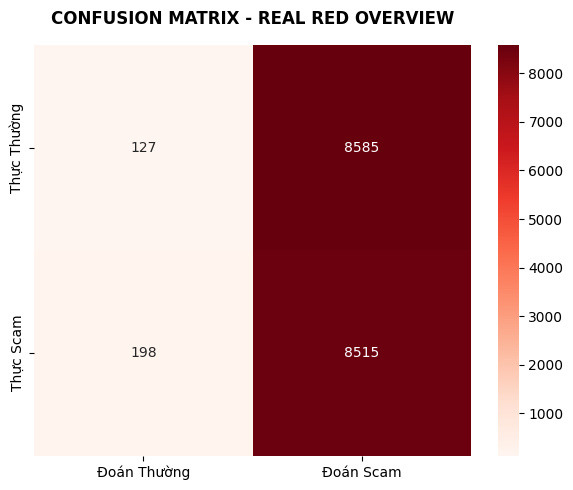

In [39]:
# Load model architecture
print('Initializing model architecture...')
base_model = ScamClassifier(CONFIG['model_name'])

print('Loading best weights...')
# Đảm bảo đường dẫn BEST_MODEL_PATH trỏ đúng vào file vừa lưu ở Epoch 10
checkpoint_weights = torch.load(BEST_MODEL_PATH, map_location=device)

# Load via strict false
base_model.load_state_dict(checkpoint_weights, strict=False)
model = base_model.to(device)
model.eval()

# Metrics storage
labels_all = []
preds_all = []

print('\nEvaluating on test set...')
with torch.no_grad():
    for batch in test_loader:
        # Transfer memory non-blocking
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        metadata = batch['metadata'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        # Safe inference precision
        with torch.amp.autocast('cuda'):
            logits = model(input_ids, attention_mask, metadata)
            
        preds = torch.argmax(logits, dim=1)
        
        labels_all.extend(labels.cpu().numpy())
        preds_all.extend(preds.cpu().numpy())

# Display final matrix
cm = confusion_matrix(labels_all, preds_all)

# Plot red heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,             # Show sample count
    fmt='d',                # Integer format
    cmap='Reds',            # Red color active
    xticklabels=['Đoán Thường', 'Đoán Scam'], 
    yticklabels=['Thực Thường', 'Thực Scam']
)
plt.title('CONFUSION MATRIX - REAL RED OVERVIEW', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()

# Save image file
plt.savefig('/kaggle/working/confusion_matrix_fixed.png', dpi=300)
plt.show()

In [ ]:
# Plot training history
import matplotlib.pyplot as plt

if history:
    steps  = [h['global_step'] for h in history]
    f1s    = [h['val_f1']      for h in history]
    losses = [h['val_loss']    for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(steps, f1s,    marker='o')
    axes[0].set_title('Val F1 Score')
    axes[0].set_xlabel('Global Step')
    axes[0].set_ylabel('F1')
    axes[0].grid(True)

    axes[1].plot(steps, losses, marker='o', color='orange')
    axes[1].set_title('Val Loss')
    axes[1].set_xlabel('Global Step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)

    plt.tight_layout()
    plot_path = os.path.join(CONFIG['output_dir'], 'training_curve.png')
    plt.savefig(plot_path)
    plt.show()
    print(f' Plot saved → {plot_path}')
else:
    print('No history to plot.')

In [ ]:
# Inference (dùng sau khi train)
def predict(texts: list[str], has_urls=None, verified=None, n_subs=None):
    """Trả về list tuple (label, confidence)"""
    if has_urls is None:
        has_urls = [0.0] * len(texts)
    if verified is None:
        verified = [0.0] * len(texts)
    if n_subs is None:
        n_subs   = [0.0] * len(texts)

    model.eval()
    results = []

    for i in range(0, len(texts), 32):
        batch_texts = texts[i:i+32]
        enc = tokenizer(
            batch_texts, max_length=CONFIG['max_length'],
            padding='max_length', truncation=True, return_tensors='pt'
        )
        meta = torch.tensor(
            [[has_urls[j], verified[j], n_subs[j]] for j in range(i, min(i+32, len(texts)))],
            dtype=torch.float
        ).to(device)

        with torch.no_grad(), autocast():
            logits = model(enc['input_ids'].to(device), enc['attention_mask'].to(device), meta)
            probs  = torch.softmax(logits, dim=1)

        for prob in probs:
            label = 'SCAM' if prob[1] > 0.5 else 'NOT SCAM'
            conf  = prob[1].item()
            results.append((label, conf))

    return results

# Test thử
samples = [
    "Chúc mừng bạn đã trúng thưởng 100 triệu đồng! Liên hệ ngay để nhận giải.",
    "Hôm nay trời đẹp quá, đi chơi thôi mọi người ơi!",
    "Đầu tư tiền ảo sinh lời 200%/tháng, cam kết hoàn vốn 100%."
]
for text, (label, conf) in zip(samples, predict(samples)):
    print(f'[{label} | {conf:.3f}] {text[:60]}...')